# Supp. fig. 8
Kidney sex specific within each genotype

In [7]:
import pandas as pd
import PyComplexHeatmap as pch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

lfc_cutoff = 1
padj_cutoff = 0.01


In [8]:
tissue_path = f"/share/crsp/lab/seyedam/share/igvf_pipeline/figures/degs/Kidney/results_de_analysis_between_sex_within_geno.csv"

df_genes = pd.read_csv(tissue_path, index_col=0)
df_genes.reset_index(inplace=True)



In [9]:
df_filtered = df_genes[(df_genes['log2FoldChange'].abs() >= lfc_cutoff) & (df_genes['padj'] <= padj_cutoff)]


In [10]:
celltype= 'proximal tubule epithelial cell'

In [11]:
upset_df = df_filtered[df_filtered['celltype'] == celltype]


## GO terms for each category

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
import textwrap


In [13]:
upset_df['comparison'].value_counts()

comparison
Sex_Female_vs_Male    15051
Name: count, dtype: int64

In [15]:
gtf_file = '/share/crsp/lab/seyedam/share/igvf_splitseq/ref/gencode.vM32.chr_patch_hapl_scaff.annotation.gtf'
gtf_df = pd.read_csv(gtf_file, sep='\t', comment='#', header=None)

gtf_df['gene_name'] = gtf_df[8].str.extract('gene_name "([^"]+)"')
gtf_df['gene_type'] = gtf_df[8].str.extract('gene_type "([^"]+)"')

# Select only the columns of interest
gene_info_df = gtf_df[['gene_name', 'gene_type']].dropna().drop_duplicates()



In [28]:
merged_sex_df = pd.merge(upset_df, gene_info_df, left_on='gene_name', right_on='gene_name', how='left')


In [29]:
merged_sex_df['gene_type'].value_counts()

gene_type
protein_coding                        9869
lncRNA                                3585
TEC                                    886
processed_pseudogene                   334
unprocessed_pseudogene                 217
transcribed_processed_pseudogene        52
transcribed_unprocessed_pseudogene      23
pseudogene                               8
misc_RNA                                 6
snoRNA                                   6
transcribed_unitary_pseudogene           4
scaRNA                                   3
snRNA                                    2
translated_unprocessed_pseudogene        2
IG_C_gene                                2
TR_C_gene                                1
ribozyme                                 1
Name: count, dtype: int64

In [30]:
colors = {'Up in females': 'hotpink', 'Up in males': 'dodgerblue'}


In [31]:
import pandas as pd

# Add sex bias category if you haven’t already
merged_sex_df['sex_bias'] = merged_sex_df['log2FoldChange'].apply(
    lambda x: 'Up in females' if x > 0 else ('Up in males' if x < 0 else 'Zero')
)

# Count number of upregulated genes per genotype & direction
sex_bias_counts = (
    merged_sex_df[merged_sex_df['sex_bias'] != 'Zero']
    .groupby(['genotype', 'sex_bias'])
    .size()
    .reset_index(name='count')
)


In [32]:
plot_df = sex_bias_counts.pivot_table(
    index='genotype',
    columns='sex_bias',
    values='count',
    fill_value=0
)

# Force column order: Female, then Male
plot_df = plot_df[['Up in females', 'Up in males']]



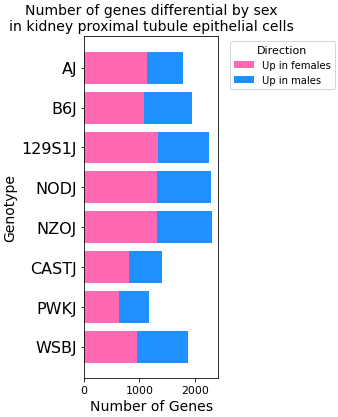

In [33]:
genotype_categories = ['AJ', 'B6J', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']
plot_df = plot_df.reindex(index=genotype_categories[::-1])

fig, ax = plt.subplots(figsize=(5, 6))

bottom = pd.Series(0, index=plot_df.index)

for sex_bias in ['Up in females', 'Up in males']:
    ax.barh(
        plot_df.index,
        plot_df[sex_bias],
        left=bottom,
        color=colors[sex_bias],
        label=sex_bias
    )
    bottom += plot_df[sex_bias]

# Smaller font sizes
ax.set_xlabel('Number of Genes', fontsize=14)
ax.set_ylabel('Genotype', fontsize=14)
ax.set_title('Number of genes differential by sex\nin kidney proximal tubule epithelial cells',
             fontsize=14)  # was 16, now a bit smaller

# Y-axis (genotype row names): keep readable
ax.tick_params(axis='y', labelsize=16)

# X-axis: smaller ticks
ax.tick_params(axis='x', labelsize=11)

# Legend: smaller
ax.legend(title='Direction', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()



In [256]:
# Store enrichment results for each genotype
enrichr_dfs = []

genos = merged_sex_df['genotype'].unique()

# FEMALE
for geno in genos:
    print(f"Running enrichment for: {geno}", flush=True)
    merged_sex_df_pc_geno = merged_sex_df_pc[
        (merged_sex_df_pc['genotype'] == geno) & (merged_sex_df_pc['log2FoldChange'] > 0)
    ]
    gene_list = merged_sex_df_pc_geno['gene_name'].drop_duplicates().tolist()
    print(f"{len(gene_list)} genes", flush=True)

    if len(gene_list) < 10:
        print(f"Skipping {geno}: fewer than 10 genes ({len(gene_list)})")
        continue

    enr = gp.enrichr(
        gene_list=gene_list,
        organism='Mouse',
        gene_sets=[
            'Reactome_Pathways_2024',
            'MGI_Mammalian_Phenotype_Level_4_2024',
            'KOMP2_Mouse_Phenotypes_2022',
            'GO_Cellular_Component_2023',
            'GO_Biological_Process_2023'
        ]
    )

    df_enr = enr.results
    df_enr = df_enr[df_enr['Adjusted P-value'] <= 0.05]

    if df_enr.empty:
        print(f"No significant terms for {geno}")
        continue

    df_enr['Genotype'] = geno
    df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])

    enrichr_dfs.append(df_enr)


Running enrichment for: B6J
695 genes
Running enrichment for: AJ
781 genes


/tmp/ipykernel_624204/2615939914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/2615939914.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


Running enrichment for: 129S1J
888 genes


/tmp/ipykernel_624204/2615939914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/2615939914.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


Running enrichment for: NODJ
852 genes


...

/tmp/ipykernel_624204/2615939914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/2615939914.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


Running enrichment for: PWKJ
429 genes


/tmp/ipykernel_624204/2615939914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/2615939914.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


Running enrichment for: CASTJ
536 genes


/tmp/ipykernel_624204/2615939914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/2615939914.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])
/tmp/ipykernel_624204/2615939914.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

In [257]:

# Combine all results
all_enrichr_females = pd.concat(enrichr_dfs, ignore_index=True)


In [258]:
all_enrichr_females_filt = all_enrichr_females[all_enrichr_females['Adjusted P-value'] < 0.01]

In [259]:
all_enrichr_females_filt['Genotype'].value_counts()

Genotype
129S1J    11
B6J        9
CASTJ      9
NODJ       8
WSBJ       6
NZOJ       4
PWKJ       1
Name: count, dtype: int64

In [260]:
all_enrichr_females_sorted = all_enrichr_females.sort_values(['Genotype', 'Adjusted P-value'])

# Take top 2 per genotype
all_enrichr_females_top2 = all_enrichr_females_sorted.groupby('Genotype').head(5).copy()

# Add -log10(Adjusted P-value) if you haven’t yet
all_enrichr_females_top2['-log10(Adjusted P-value)'] = -np.log10(all_enrichr_females_top2['Adjusted P-value'])


In [261]:
# Keep only needed columns
heatmap_df = all_enrichr_females_top2[['Term', 'Genotype', '-log10(Adjusted P-value)']]


# Pivot to make GO terms × Gvcenotype matrix
heatmap_mat = heatmap_df.pivot_table(
    index='Term',
    columns='Genotype',
    values='-log10(Adjusted P-value)',
    fill_value=0
)
#heatmap_mat['AJ'] = 0
genotype_categories = ['AJ', 'B6J', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']

# Reindex columns to match your order
heatmap_mat = heatmap_mat.reindex(columns=genotype_categories)

def split_term(term, max_length=60):
    if len(term) <= max_length:
        return term
    else:
        # Try to split on the last space before max_length
        split_idx = term.rfind(' ', 0, max_length)
        if split_idx == -1:
            split_idx = max_length
        return term[:split_idx] + '\n' + term[split_idx+1:]

# Apply to index
#heatmap_mat.index = heatmap_mat.index.to_series().apply(split_term)


/tmp/ipykernel_624204/3367325436.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


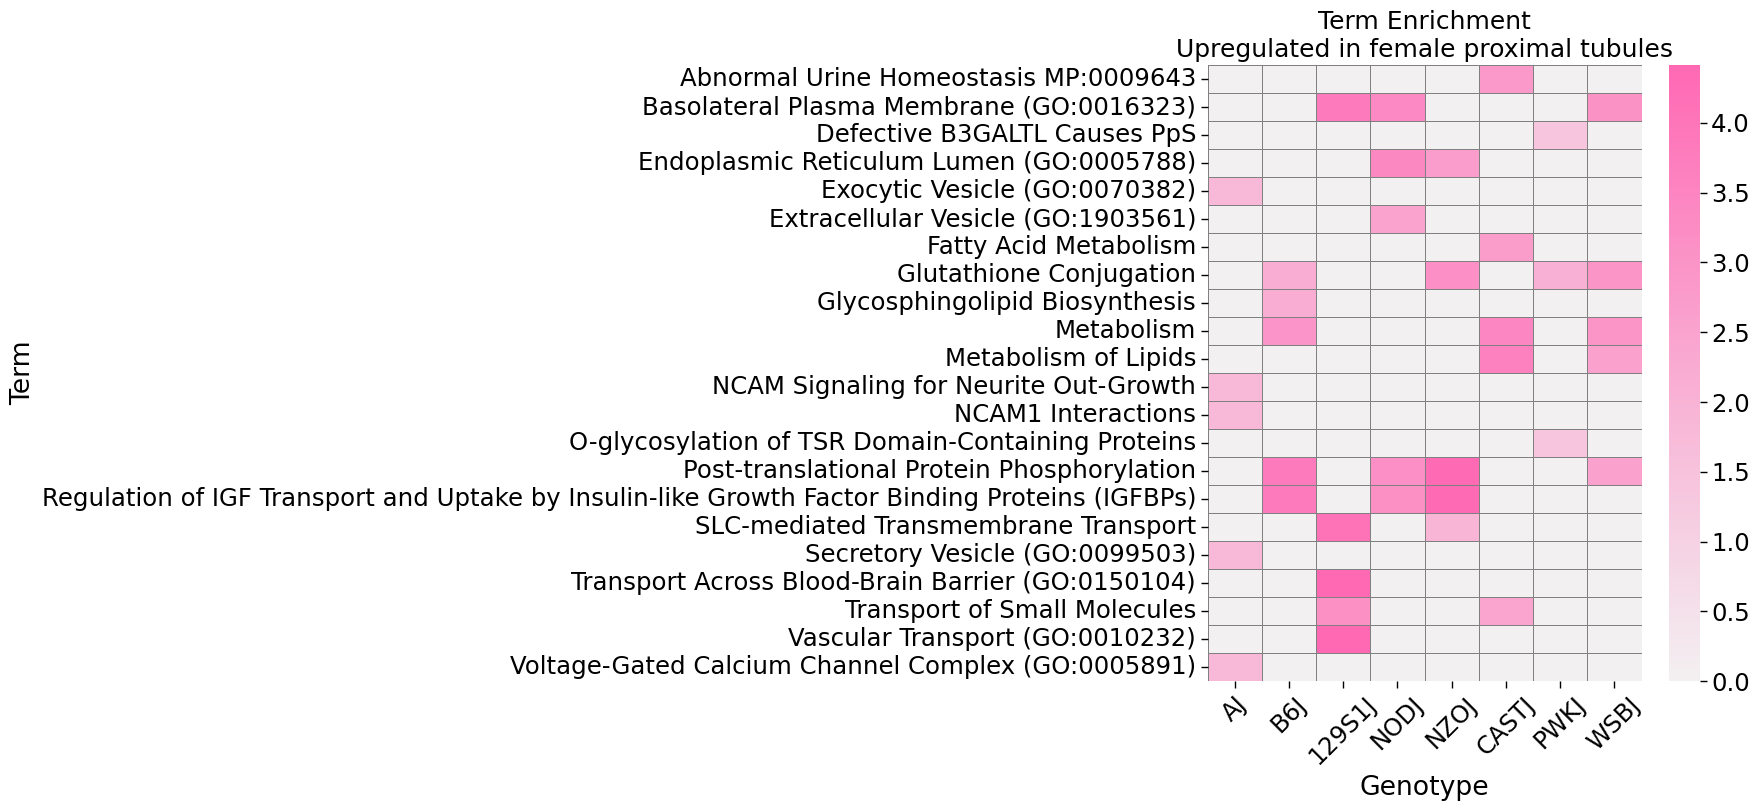

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt

pink_cmap = sns.light_palette("hotpink", as_cmap=True)


plt.figure(figsize=(7, 8))
sns.heatmap(
    heatmap_mat,
    linewidths=0.5,
    cmap=pink_cmap,
    linecolor='gray'
)

plt.xticks(rotation=45, ha='center')

plt.title('Term Enrichment\nUpregulated in female proximal tubules', fontsize=18)
plt.xlabel('Genotype')
plt.ylabel('Term')
plt.tight_layout()
plt.show()


In [263]:
import gseapy as gp
import numpy as np

# Store enrichment results for each genotype
enrichr_dfs = []

genos = merged_sex_df_pc['genotype'].unique()

# mALES
for geno in genos:
    print(f"Running enrichment for: {geno}", flush=True)
    merged_sex_df_pc_geno = merged_sex_df_pc[
        (merged_sex_df_pc['genotype'] == geno) & (merged_sex_df_pc['log2FoldChange'] < 0)
    ]
    gene_list = merged_sex_df_pc_geno['gene_name'].drop_duplicates().tolist()
    print(f"{len(gene_list)} genes", flush=True)

    if len(gene_list) < 10:
        print(f"Skipping {geno}: fewer than 10 genes ({len(gene_list)})")
        continue

    enr = gp.enrichr(
        gene_list=gene_list,
        organism='Mouse',
        gene_sets=[
            'Reactome_Pathways_2024',
            'MGI_Mammalian_Phenotype_Level_4_2024',
            'KOMP2_Mouse_Phenotypes_2022',
            'GO_Cellular_Component_2023',
            'GO_Biological_Process_2023'
        ]
    )

    df_enr = enr.results
    df_enr = df_enr[df_enr['Adjusted P-value'] <= 0.05]

    if df_enr.empty:
        print(f"No significant terms for {geno}")
        continue

    df_enr['Genotype'] = geno
    df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])

    enrichr_dfs.append(df_enr)


Running enrichment for: B6J
579 genes
Running enrichment for: AJ
418 genes


/tmp/ipykernel_624204/3070402603.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/3070402603.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


Running enrichment for: 129S1J
592 genes


/tmp/ipykernel_624204/3070402603.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/3070402603.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


Running enrichment for: NODJ
587 genes


/tmp/ipykernel_624204/3070402603.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/3070402603.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


No significant terms for NODJ
Running enrichment for: NZOJ
659 genes
Running enrichment for: WSBJ
591 genes


/tmp/ipykernel_624204/3070402603.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/3070402603.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


No significant terms for WSBJ
Running enrichment for: PWKJ
368 genes
No significant terms for PWKJ
Running enrichment for: CASTJ
407 genes


/tmp/ipykernel_624204/3070402603.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['Genotype'] = geno
/tmp/ipykernel_624204/3070402603.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enr['-log10(Adjusted P-value)'] = -np.log10(df_enr['Adjusted P-value'])


In [264]:
import pandas as pd

# Combine all results
all_enrichr_males = pd.concat(enrichr_dfs, ignore_index=True)

# Keep only needed columns
heatmap_df = all_enrichr_males[['Term', 'Genotype', '-log10(Adjusted P-value)']]

# Pivot to make GO terms × Gvcenotype matrix
heatmap_mat = heatmap_df.pivot_table(
    index='Term',
    columns='Genotype',
    values='-log10(Adjusted P-value)',
    fill_value=0
)



In [267]:
heatmap_mat['NODJ'] = 0
heatmap_mat['NZOJ'] = 0
heatmap_mat['PWKJ'] = 0
heatmap_mat['WSBJ'] = 0

genotype_categories = ['AJ', 'B6J', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']

# Reindex columns to match your order
heatmap_mat = heatmap_mat.reindex(columns=genotype_categories)



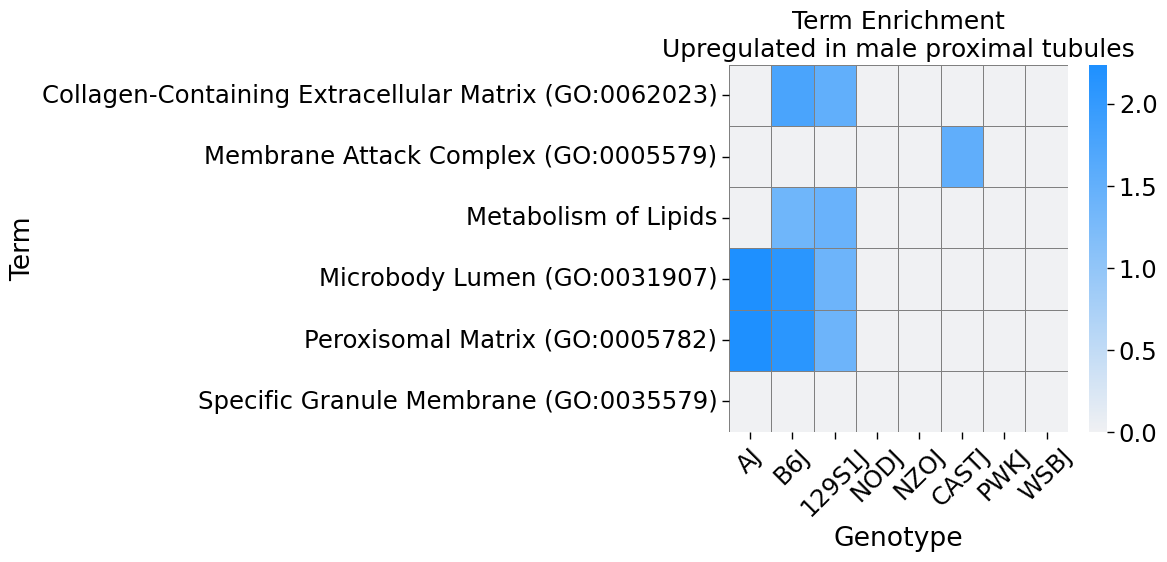

In [269]:
import seaborn as sns
import matplotlib.pyplot as plt

blue_cmap = sns.light_palette("dodgerblue", as_cmap=True)


plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_mat,
    linewidths=0.5,
    cmap=blue_cmap,
    linecolor='gray'
)

plt.xticks(rotation=45, ha='center')

plt.title('Term Enrichment\nUpregulated in male proximal tubules', fontsize=18)
plt.xlabel('Genotype')
plt.ylabel('Term')
plt.tight_layout()
plt.show()
